# Intro

A project to learn time series analysis:
- Visualization
- Forecasting
- Interpretation

[Dataset](https://open.toronto.ca/dataset/toronto-island-ferry-ticket-counts/)

This dataset provides near real-time information on ferry ticket sales and ticket redemptions. The counts are provided in 15 minute intervals and are updated hourly. They encompass all product types and include both online and POS-kiosk sales.

In [1]:
import os
os.chdir("../")
cwd = os.getcwd()
print(cwd)

/home/ruchirich/Documents/repositories/toronto-open-data/toronto-island-park


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math

# Refresh data from Toront Open Data

In [3]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "toronto-island-ferry-ticket-counts"}
download_file = cwd+"/data/toronto-island-ferry-ticket-counts.csv"

download_data(params, download_file)

In [4]:
df = pd.read_csv(download_file, index_col='Timestamp', parse_dates=True, date_format="ISO8601", usecols=['Timestamp', 'Sales Count', 'Redemption Count'])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 237165 entries, 2025-01-20 23:30:00 to 2015-05-01 13:30:00
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Redemption Count  237165 non-null  int64
 1   Sales Count       237165 non-null  int64
dtypes: int64(2)
memory usage: 5.4 MB


In [5]:
df.head()

,Redemption Count,Sales Count
Timestamp,,
2025-01-20 23:30:00,1,0
2025-01-20 23:15:00,4,0
2025-01-20 23:00:00,1,0
2025-01-20 22:30:00,2,0
2025-01-20 22:15:00,2,1


In [6]:
max = pd.to_datetime(df.index.strftime("%Y-%m-%d").unique().max())
min = pd.to_datetime(df.index.strftime("%Y-%m-%d").unique().min())

# Attribute descriptions

`id`: Unique identifier for each 15 minutes time interval

`Timestamp`: The 15 minute interval (end time) that the data represents

`Redemption Count`: The ticket redemption count between the previous and current timestamp

`Sales Count`: The ticket sales count between the previous and current timestamp

In [7]:
Sales = df['Sales Count']
Redemption = df['Redemption Count']

diff = Sales - Redemption

# Monthly trend

## Time plot and Seasonal plot

In [30]:
sales_monthly = Sales.groupby([Sales.index.year, Sales.index.month]).sum()
sales_monthly.index.names = ['Year', 'Month']

redemption_monthly = Redemption.groupby([Redemption.index.year, Redemption.index.month]).sum()
redemption_monthly.index.names = ['Year', 'Month']

In [69]:
sales_monthly.index[1][1]

6

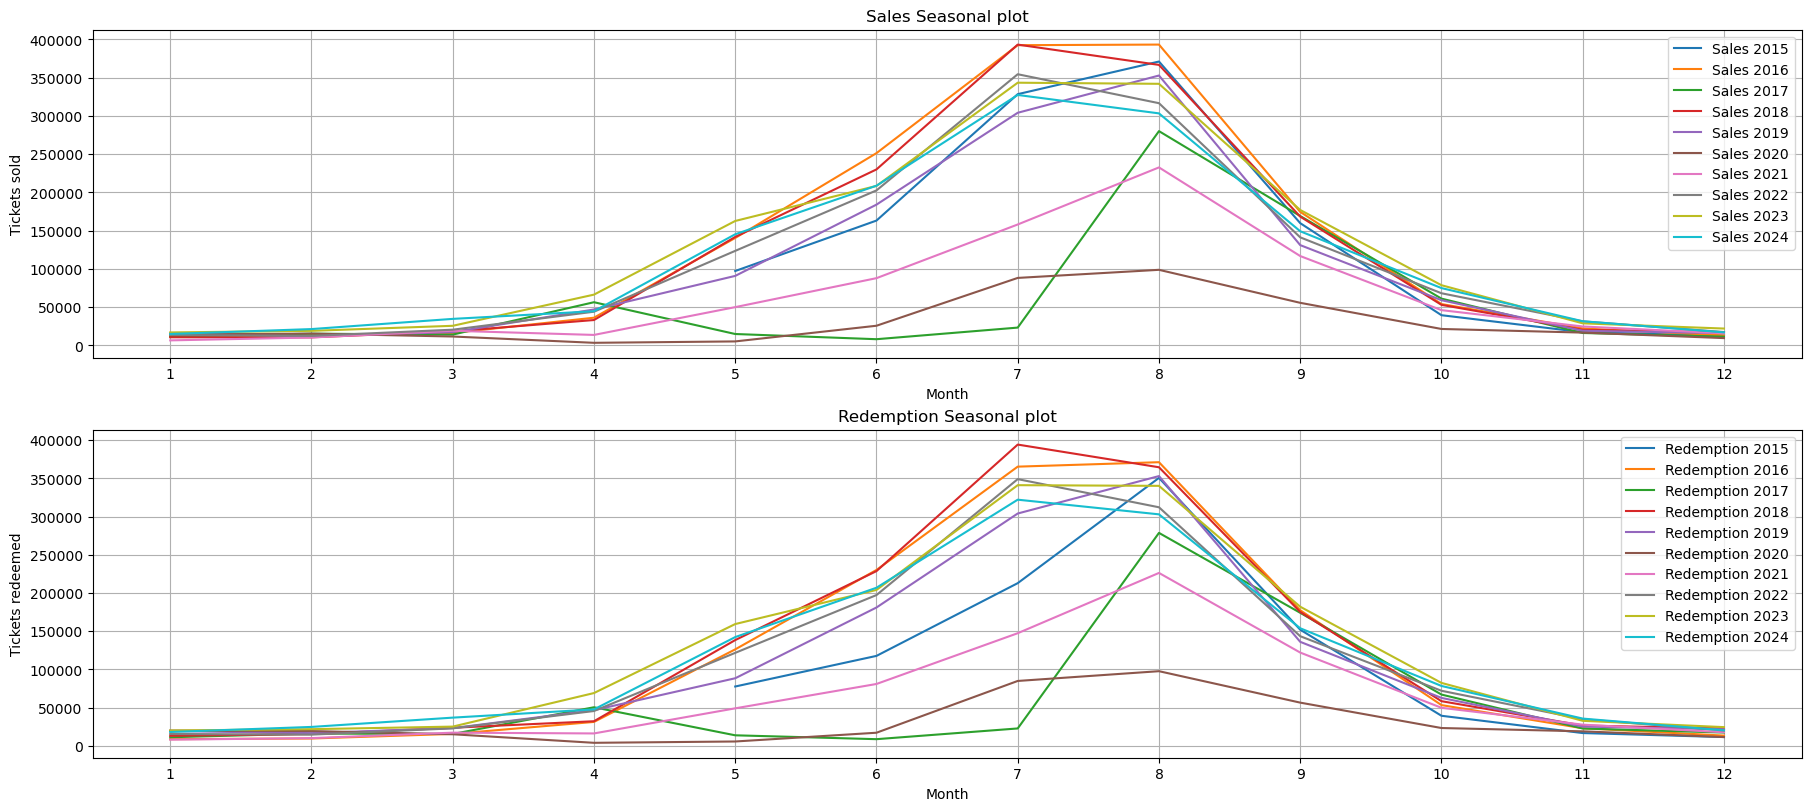

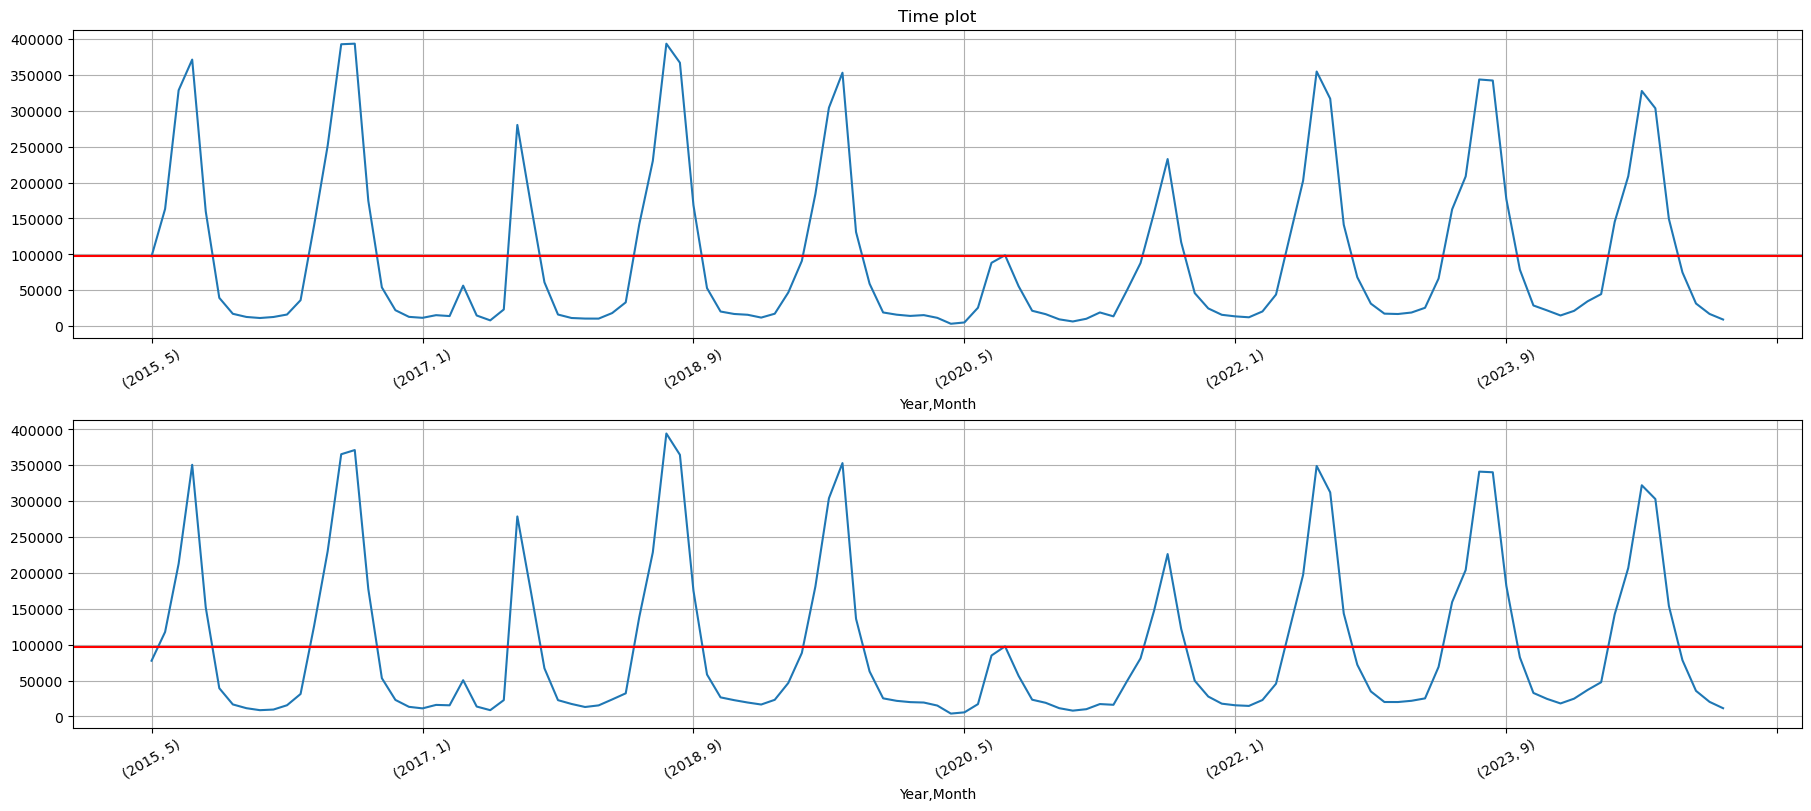

In [66]:
fig_seasonal_line_plot, ax = plt.subplots(2,1, constrained_layout=True)

months = Sales.index.month.unique()
ax[0].set_xticks(months)
for year in range(min.year, max.year):
    sales_monthly[year].plot.line(
        ax=ax[0],
        title='Sales Seasonal plot',
        label = f"Sales {year}",
        ylabel='Tickets sold',
        figsize=(18, 8),
        legend=True,
        grid=True)

ax[1].set_xticks(months)
for year in range(min.year, max.year):
    redemption_monthly[year].plot.line(
        ax=ax[1],
        title='Redemption Seasonal plot',
        label = f"Redemption {year}",
        ylabel='Tickets redeemed',
        figsize=(18, 8),
        legend=True,
        grid=True)

fig_seasonal_line_plot.savefig(fname='output/figures/seasonal_lineplot')

fig_line_plot, ax = plt.subplots(2,1, constrained_layout=True)

ax[0].axhline(y=sales_monthly.mean(), c='r')
sales_monthly.plot.line(ax=ax[0], figsize=(18, 8), grid=True, rot=30, title='Time plot')

ax[1].axhline(y=redemption_monthly.mean(), c='r')
redemption_monthly.plot.line(ax=ax[1], figsize=(18, 8), grid=True, rot=30)

fig_line_plot.savefig(fname='output/figures/lineplot')

In [37]:
fig.savefig(fname='plot')

## Seasosnal boxplot

In [10]:
sales_monthly = pd.DataFrame(data=sales_monthly).T.melt()
redemption_monthly = pd.DataFrame(data=redemption_monthly).T.melt()

[Text(0.5, 1.0, 'Redemption count seasonal plot')]

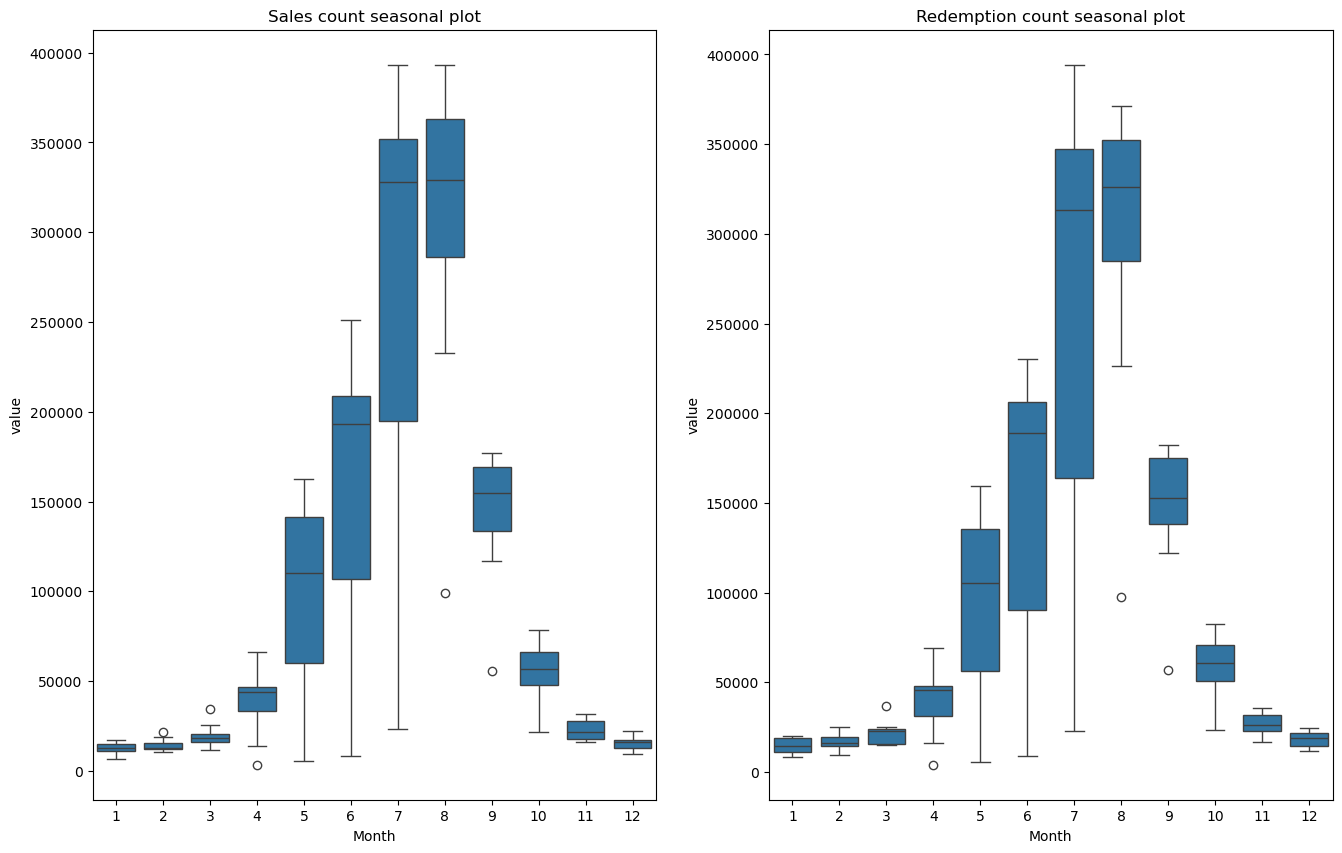

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2)

fig.set_figwidth(16)
fig.set_figheight(10)

sns.boxplot(
    data=sales_monthly,
    x="Month",
    y="value",
    ax=ax1
    ).set(title='Sales count seasonal plot')

sns.boxplot(
    data=redemption_monthly,
    x="Month",
    y="value",
    ax=ax2
    ).set(title='Redemption count seasonal plot')

In [12]:
sales_hourly = Sales.groupby([Sales.index.year, Sales.index.month, Sales.index.day, Sales.index.dayofweek, Sales.index.hour]).sum()
redemption_hourly = Redemption.groupby([Redemption.index.year, Redemption.index.month, Redemption.index.day, Sales.index.dayofweek, Redemption.index.hour]).sum()
sales_hourly = pd.DataFrame(data=sales_hourly).T.melt()
redemption_hourly = pd.DataFrame(data=redemption_hourly).T.melt()

[Text(0.5, 1.0, 'Redemption count seasonal plot'),
 Text(0.5, 0, 'Hour of the day'),
 Text(0, 0.5, 'Redemption Count')]

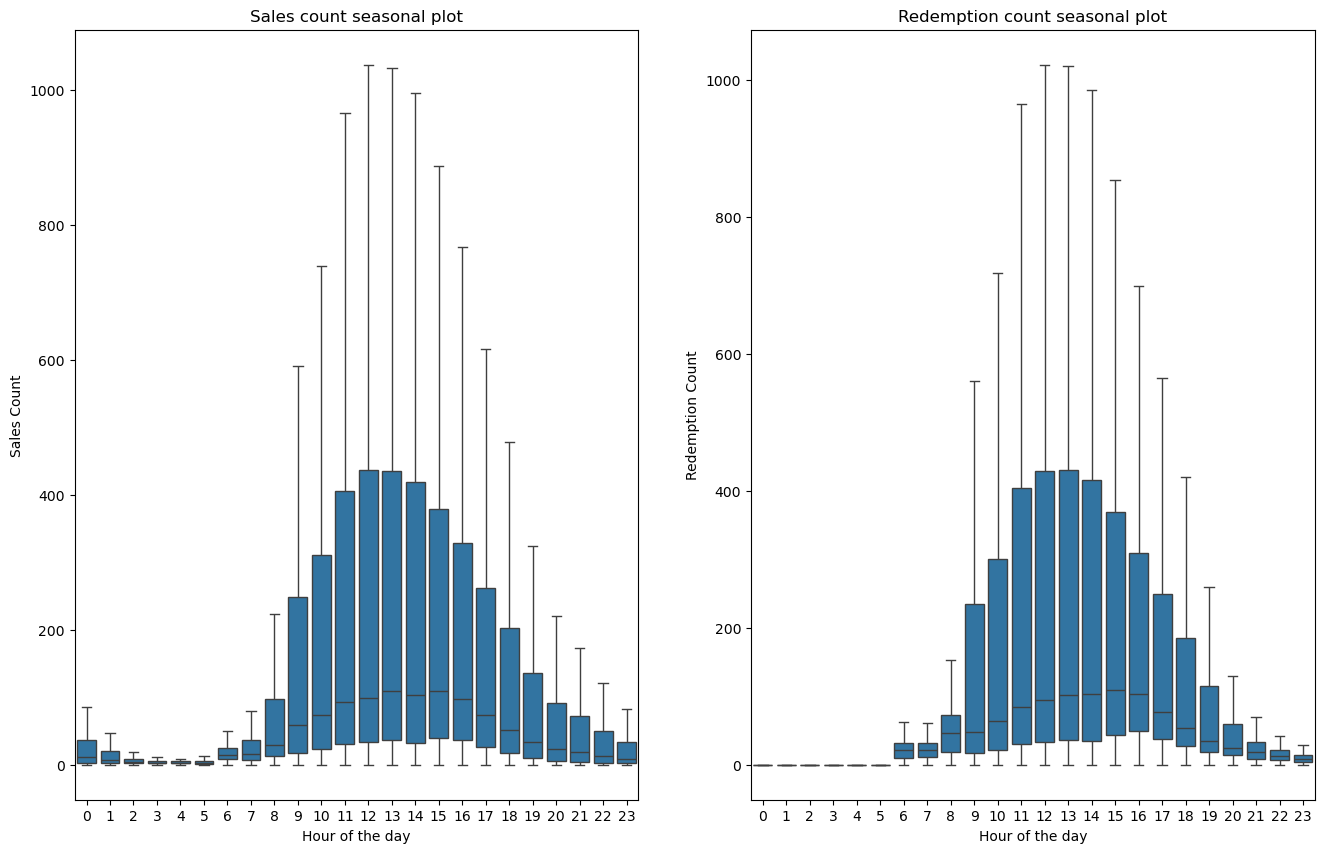

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2)

fig.set_figwidth(16)
fig.set_figheight(10)

sns.boxplot(
    data=sales_hourly,
    x="variable_4",
    y="value",
    ax=ax1,
    fliersize=2,
    showfliers=False
    ).set(title='Sales count seasonal plot', xlabel='Hour of the day', ylabel='Sales Count')

sns.boxplot(
    data=redemption_hourly,
    x="variable_4",
    y="value",
    ax=ax2,
    fliersize=2,
    showfliers=False
    ).set(title='Redemption count seasonal plot', xlabel='Hour of the day', ylabel='Redemption Count')

In [14]:
sales_daily = Sales.groupby([Sales.index.year, Sales.index.month, Sales.index.day, Sales.index.dayofweek]).sum()
redemption_daily = Redemption.groupby([Redemption.index.year, Redemption.index.month, Redemption.index.day, Sales.index.dayofweek]).sum()
sales_daily = pd.DataFrame(data=sales_daily).T.melt()
redemption_daily = pd.DataFrame(data=redemption_daily).T.melt()

[Text(0.5, 1.0, 'Redemption count seasonal plot'),
 Text(0.5, 0, 'Day of the week'),
 Text(0, 0.5, 'Redemption Count')]

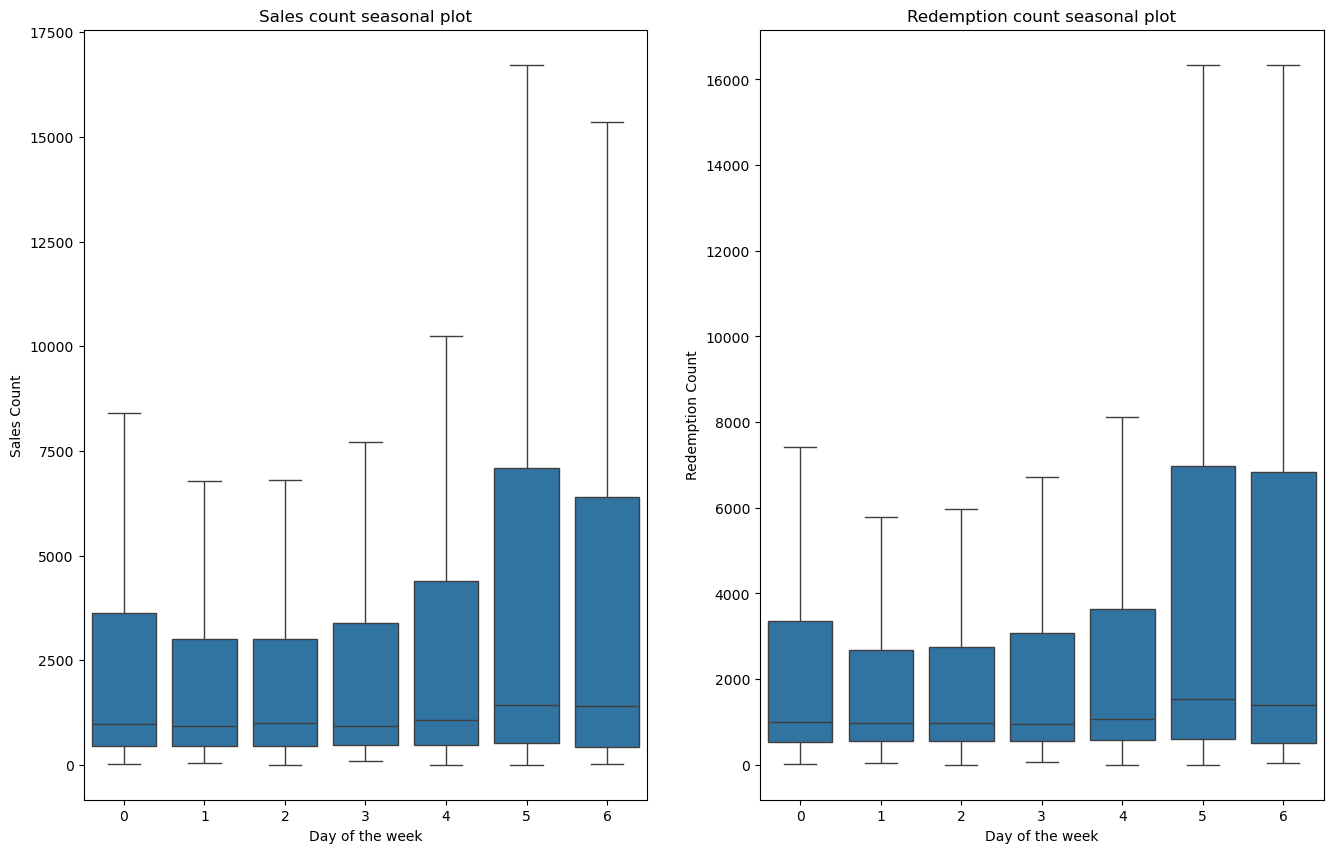

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2)

fig.set_figwidth(16)
fig.set_figheight(10)

sns.boxplot(
    data=sales_daily,
    x="variable_3",
    y="value",
    ax=ax1,
    fliersize=2,
    showfliers=False
    ).set(title='Sales count seasonal plot', xlabel='Day of the week', ylabel='Sales Count')

sns.boxplot(
    data=redemption_daily,
    x="variable_3",
    y="value",
    ax=ax2,
    fliersize=2,
    showfliers=False
    ).set(title='Redemption count seasonal plot', xlabel='Day of the week', ylabel='Redemption Count')

## Scatterplot

<Axes: title={'center': 'Scatter plot'}, xlabel='Sales Count', ylabel='Redemption Count'>

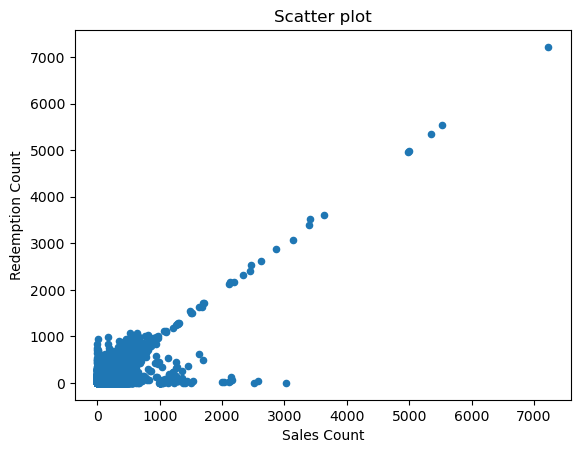

In [16]:
df.plot.scatter(x='Sales Count',
                y='Redemption Count',
                title='Scatter plot')

## ACF Plot

Autocorrelation measures strength of the linear relationship between lagged values of a time series

We expect 95% of the peaks to occur between ± 2/√T for a white noise series (no autocorrelation), where T is the length of the whole series.

If more than 5% of the peaks are outside of these lines, then the series is probably not white noise.

In [17]:
2/math.sqrt(120)

0.18257418583505536

In [23]:
sales_monthly = sales_monthly.set_index(keys=['Year', 'Month'])

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

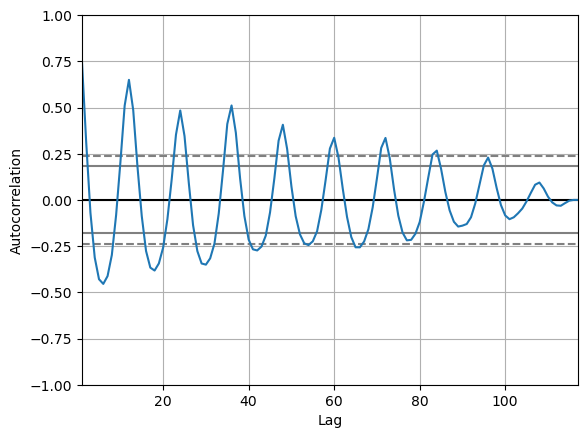

In [24]:
pd.plotting.autocorrelation_plot(sales_monthly)

From the ACF plot:
- Seasonality in data, repeats annually.
- Decreasing trend
- The similarity in pattern decays with increasing time lag

# Data preparation

In [25]:
log_sales = np.log(sales_monthly)

<Axes: xlabel='Year,Month'>

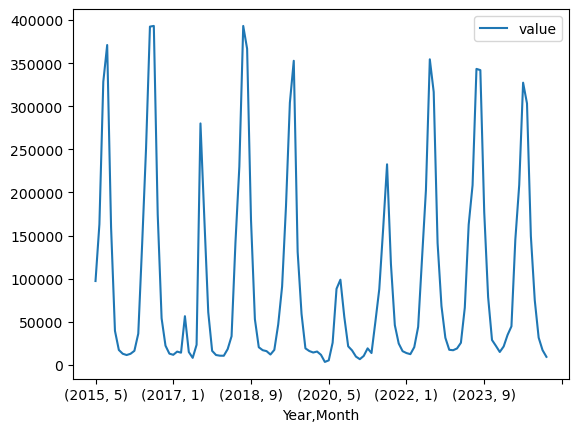

In [26]:
sales_monthly.plot.line()

<Axes: xlabel='Year,Month'>

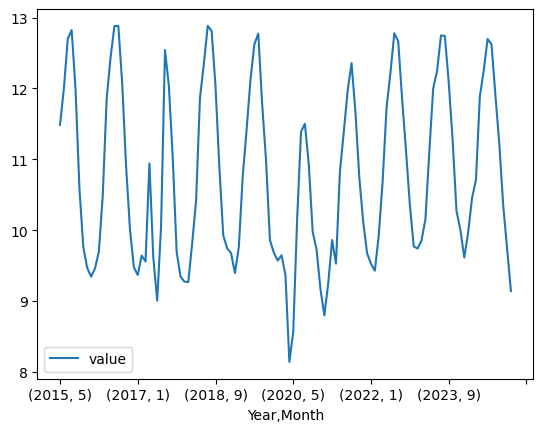

In [27]:
log_sales.plot.line()

# Smoothing and decomposing

Time series components

Trend, seasonality and residual

Additive seasonal effect:

Y_t = T_t + S_t + e_t

Multiplicative seasonal effect:

Y_t = T_t * S_t * e_t

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose